In [90]:
import sklearn
from sklearn import datasets
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier


# Lab assignment

## Part-1: Python

Multi-class classification with ANN, do the following in python

**Q-1.1 Import and explore:** 

(1) Import MNIST from Sklearn, (2) print the shapes of the data and the target matrices (3) visualize a random MNIST image


In [ ]:
# import MNIST dataset
from sklearn.datasets import fetch_openml
data = fetch_openml('mnist_784', version=1, as_frame=False)

(70000, 784)
(70000,)
(784,)


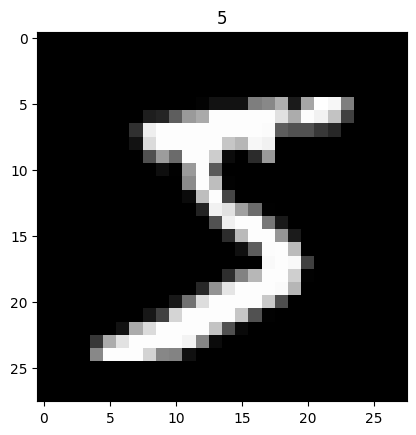

In [ ]:
# data
X = data.data

# target variable
y = data.target

# data shape
print(X.shape) # data shape
print(y.shape) # target variable shape
print(X[0].shape) # image shape

# view first image
plt.imshow(X[0].reshape(28, 28), cmap='gray')
plt.title(y[0])
plt.show()

**Q-1.2 Split data**: 

Break the data into an 80-20 training-test split. 

In [27]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

**Q-1.3 Logistic regression**

Train a multi-class logistic regression model as a base-line for comparison, do hyper-parameter search by varying  the `L2` regularization parameter, and record the training-validation error. Determine and report the optimal value of the `L2` regularization parameter. At the end train your best fit model using the optimal hyper-parameter and report the training-test error.

In [ ]:
# create a vector of L2 parameters
C = [0.001, 0.01, 0.1, 1, 10, 100]

# create results vectors
train_error_results = []
val_error_results = []

for c in C: # loop through all L2 values defined above

  # create logistic regression model with L2
  baseline_model = LogisticRegression(
    C = c # L2 value
  )

  # rescale X
  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train)
  X_val = scaler.fit_transform(X_val)

  # fit model
  baseline_model.fit(X_train, y_train)

  # train predictions
  y_train_pred = baseline_model.predict(X_train)
  # train error
  training_error = 1 - accuracy_score(y_train, y_train_pred)
  train_error_results.append(training_error) # save train error

  # validation predictions
  y_val_pred = baseline_model.predict(X_val)
  # validation error
  val_error = 1 - accuracy_score(y_val, y_val_pred)
  val_error_results.append(val_error) # save validation error


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
   

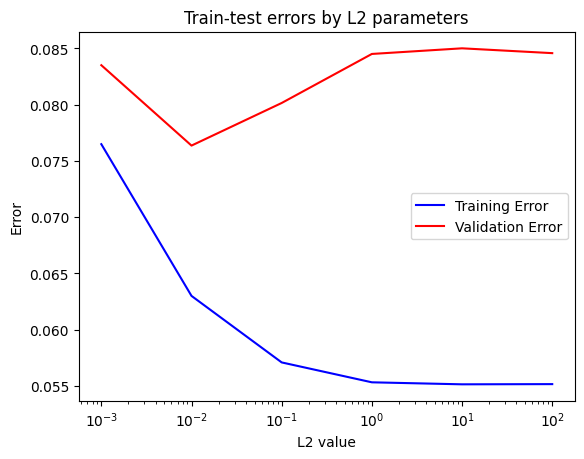

In [48]:
# plot train and validation errors by L2 parameters
fig, ax = plt.subplots()
ax.set_xscale('log')
ax.plot(C,train_error_results,"-", color='blue', label ='Training Error')
ax.plot(C,val_error_results,"-", color='red', label = 'Validation Error')
ax.legend(loc='right')
ax.set_xlabel('L2 value')
ax.set_ylabel('Error')
plt.title('Train-test errors by L2 parameters')
plt.show()

**Comment:** The result shows that although training error keeps improving as L2 increases, validation error is lowest at L2=0.01. So, the optimal L2 value is 0.01, a strong regularization strength.

In [51]:
# retrain the model with optimial L2=0.01
# rescale X
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.fit_transform(X_val)

# fit model with L2=0.01
logit_model = LogisticRegression(C = 0.01, max_iter=100)
logit_model.fit(X_train, y_train)

# train error
train_predict = logit_model.predict(X_train)
training_error = 1 - accuracy_score(train_predict, y_train)

# validation error
val_predict = logit_model.predict(X_val)
val_error = 1 - accuracy_score(val_predict, y_val)

print('Train error: ', training_error)
print('Test error: ', val_error)

Train error:  0.06299999999999994
Test error:  0.0763571428571429


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Q-1.4: ANN training** 

* Do a multi-variable hyper-parameter search using a simplified version of `random search` for an ANN model. 
* Use the internal validation methods included with `sklearn.neural_network.MLPClassifier` for cross-validation.
    * Start with some initial guess for the hyper parameters with associate maximum step sizes
    * Introduce a `loop`, at each iteration
      * Randomly perturb the hyper-parameters (test <- current + random_change) and re-train 
      * Accept the change if you get a better model (lower validation error) ... repeat
    * **Optional**: Extend the search by using a distance metric to compute new points (see link below)

Choose 4 or more hyper-parameters to search for, e.g. `L2`,`activation`,`layer_size`, etc. Also, make sure to do early stopping during the search. Record the progression of the search in a data-frame and visualize the validation error results. 

[https://en.wikipedia.org/wiki/Random_search](https://en.wikipedia.org/wiki/Random_search)

Determine and report the optimal set of values for the parameters. At the end train your best fit model using the optimal hyper-parameter and report the training-test-validation error.

In [99]:
# set initial parameters
alpha = 0.01
lr = 0.001
activation='relu'
hidden_layer_size = 3

# set paramaters choices
alpha_search = [1, 0.1, 10, 100, 1000, 10000]
lr_search = [1, 0.5, 2, 5, 10]
activation_search = ['relu','tanh']
hidden_layer_size_search = [8, 12, 24, 32, 48, 64]

# save result in a dataframe
results = []

# set max number of iterations to search from the parameters grid
n_iterations = 20

# iterative random search
for i in range(n_iterations):

    # update hyperparameters
    new_alpha =  alpha * np.random.choice(alpha_search)
    new_lr = lr * np.random.choice(lr_search)
    new_activation = random.choice(activation_search)
    hidden_layer_size = random.choice(hidden_layer_size_search)

    # train model
    model = MLPClassifier(
        hidden_layer_sizes=(hidden_layer_size,),
        activation=new_activation,
        solver='lbfgs',
        alpha=new_alpha,
        learning_rate_init=new_lr,
        max_iter=500,
        tol=1e-4,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=10,
        random_state=42
    )
    # fit model wth train data
    model.fit(X_train, y_train)

    # evaluate on validation data
    y_pred = model.predict(X_val)
    validation_error_score = 1- accuracy_score(y_val, y_pred)

    # update results dataframe
    results.append({
        "iteration": i + 1,
        "alpha": new_alpha,
        "lr": new_lr,
        "activation": new_activation,
        "hidden_layer_size": hidden_layer_size,
        "val_error": validation_error_score
    })


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_opt

In [100]:
# display results
pd.DataFrame(results)

,iteration,alpha,lr,activation,hidden_layer_size,val_error
0,1,100.000,0.0010,relu,32,0.028857
1,2,100.000,0.0005,relu,8,0.065214
2,3,100.000,0.0100,relu,48,0.027571
3,4,1.000,0.0005,tanh,64,0.046857
4,5,0.010,0.0005,tanh,64,0.053929
5,6,0.001,0.0005,tanh,48,0.062286
6,7,0.100,0.0010,relu,12,0.087571
7,8,0.010,0.0050,relu,24,0.050214
8,9,0.100,0.0005,tanh,64,0.051571
9,10,0.100,0.0020,relu,12,0.087571


**Comment:** The result shows the optimal hypter-parameters are *alpha = 100, lr = 0.01, activation = relu, hidden_layer_size = 48*. The lowest validation error is 0.0276

In [102]:
# retrain model with optimal hypter parameters
model = MLPClassifier(
    hidden_layer_sizes=(48,),
    activation='relu',
    solver='lbfgs',
    alpha=100,
    learning_rate_init=0.01,
    max_iter=500,
    tol=1e-4,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=10,
    random_state=42
)

# fit model wth train data
model.fit(X_train, y_train)

# evaluate on validation data
y_pred = model.predict(X_train)
train_error_score = 1- accuracy_score(y_train, y_pred)

# evaluate on validation data
y_pred = model.predict(X_val)
validation_error_score = 1- accuracy_score(y_val, y_pred)

print('Train error:', train_error_score)
print('Validation error:', validation_error_score)


Train error: 0.0063750000000000195
Validation error: 0.02757142857142858


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
